<a href="https://colab.research.google.com/github/damiansl24/ML_Stock_Forecaster/blob/main/Final_Project_YISS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using the yahoo finance dataset, https://www.kaggle.com/datasets/tanavbajaj/yahoo-finance-all-stocks-dataset-daily-update,

I compiled every dataframe into a total market csv (for a given timeframe) and based on relationships between the total market and my chosen ticker, AMZN, I found values for different relationships that express stock performance. I then developed an algorithm to determine whether or not a market was bullish or bearish, defined as bearish showing a net downward trend (negative slope) and bullish as showing a net upward trend (positive slope).

In [ ]:
import requests
import chardet
import io
import pandas as pd

#loading the data
total_market_csv = "https://drive.google.com/file/d/18schLXuQxpNJvf1bdKBp0chuHM96l2dc/view?usp=sharing"
TMID = total_market_csv.split("/")[-2]
TMCSV = f"https://drive.google.com/uc?id={TMID}&export=download"

total_market = requests.get(TMCSV)
market_csv = total_market.content

mrk_enc = chardet.detect(market_csv)

MARKET = pd.read_csv(io.StringIO(market_csv.decode(mrk_enc['encoding'])))

AMZN_csv = "https://drive.google.com/file/d/1-1fffeTJX3a7mQLcU9E38osYxnJr9iMn/view?usp=sharing"
AID = AMZN_csv.split("/")[-2]
ACSV = f"https://drive.google.com/uc?id={AID}&export=download"

amzn_read = requests.get(ACSV)
AMZN_csv = amzn_read.content

AMZN_enc = chardet.detect(AMZN_csv)

AMZN = pd.read_csv(io.StringIO(AMZN_csv.decode(AMZN_enc['encoding'])))

In [ ]:
#slicing the data to match our total market time frame.
AMZN = AMZN.drop(columns = ["Dividends","Stock Splits","Volume"])
AMZN["Date"] = pd.to_datetime(AMZN["Date"],utc =True,format = "%Y-%m-%d %H:%M:%S%z")
AMZN["Date"] = AMZN["Date"].dt.normalize()

start_date = "2000-01-03 00:00:00+00:00"
end_date = "2023-01-02 00:00:00+00:00"
AMZN = AMZN[(AMZN['Date'] >= start_date) & (AMZN['Date'] <= end_date)]

AMZN.set_index("Date", inplace = True)

In [ ]:
#Lets find change in price (close - open)
AMZN["Change_percentage"] = ((AMZN["Close"] - AMZN["Open"])/AMZN["Open"])
AMZN.head()

MARKET["Change_percentage"] = ((MARKET["Close"] - MARKET["Open"])/MARKET["Open"])
#MARKET.head()

In [ ]:
alpha_vals = (AMZN["Close"] - AMZN["Open"])
for i in range(len(alpha_vals)):
  alpha_vals[i] += AMZN["Open"][i]*MARKET["Change_percentage"][i]

AMZN["Alpha"] = alpha_vals

AMZN["Alpha sums"] = AMZN["Alpha"].cumsum()

AMZN["Average"] = (AMZN['Open'] + AMZN["Close"])/2

AMZN = AMZN.drop(columns = ["Open","High","Low","Close"])

AMZN.head()

/tmp/ipython-input-2953855733.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_vals[i] += AMZN["Open"][i]*MARKET["Change_percentage"][i]
/tmp/ipython-input-2953855733.py:3: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  alpha_vals[i] += AMZN["Open"][i]*MARKET["Change_percentage"][i]


,Change_percentage,Alpha,Alpha sums,Average
Date,,,,
2000-01-03 00:00:00+00:00,0.096626,0.289372,0.289372,4.271875
2000-01-04 00:00:00+00:00,-0.040264,-0.246894,0.042478,4.182813
2000-01-05 00:00:00+00:00,-0.010638,-0.006507,0.035971,3.506250
2000-01-06 00:00:00+00:00,-0.080631,-0.294503,-0.258532,3.421875
2000-01-07 00:00:00+00:00,0.038246,0.218838,-0.039694,3.414062


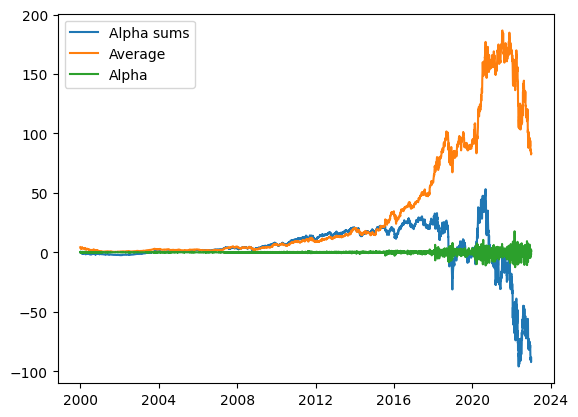

In [ ]:
import matplotlib.pyplot as plt

plt.plot(AMZN["Alpha sums"])
plt.plot(AMZN["Average"])
plt.plot(AMZN["Alpha"])
plt.legend(["Alpha sums","Average","Alpha"])

plt.show()

#the alpha sum crashing indicates that the market in recent years has outperformed amazon consistently.

In [ ]:
#Using summed alpha, I want to predict the average cost over the next 10 days.
#Doing so, I will use the polynomial fit for a higher power regression model.

import random
import numpy as np
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore", message="Polyfit may be poorly conditioned")
#There is a rankwarning for the polynomial fit, but as I only saw this fit as a viable option for the time series regression, I chose to ignore it.

random.seed(42)

def time_regression(data,n,p): #n is number of samples in training, p is point selected for starting.
#Function will return a list:[output, error]
  train = data.iloc[p-n:p].copy()
  test = data.iloc[p:p+10].copy()
  n = 1
  error = None
  while error == None or error > 5 or n <= 15:
    coef = np.polyfit(train["Alpha sums"],train["Average"],n)
    func = np.poly1d(coef)
    train_target = func(test["Alpha sums"])
    error = mean_squared_error(train_target,test["Average"])
    if n == 15 or error < 5:
      break
    else:
      n += 1
  return [train_target,error]

def time_cv(data,list_of_samples,iterations):
  length = data.shape[0]
  error = {}
  points = random.sample(range(max(list_of_samples)+10,length-10),iterations)
  for n in list_of_samples:
    error[n] = []
    for point in points:
      error[n].append(time_regression(data,n,point)[1])
  for err in error:
    error[err] = np.mean(error[err])
  min_error = list_of_samples[0]
  for sample in list_of_samples[1:]:
    if error[sample] < error[min_error]:
      min_error = sample
  return error[min_error],min_error

In [ ]:
training_k = [1,2,3,4,5,20,30,50,100,200,300,400]
m = 1000

out = time_cv(AMZN,training_k,m)
out
#this will take ~ 1 minute to run.

(np.float64(9913122710.969261), 400)

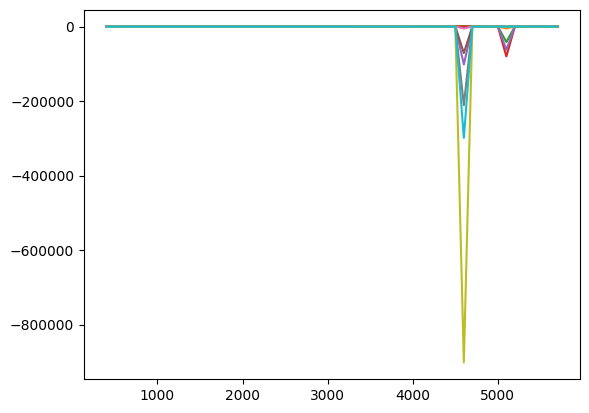

In [ ]:
#Lets validate the findings on a graph, using n optimal.
n = out[1]
x_axis = range(n+1,AMZN.shape[0]-10,100)
y_axis = []
for i in x_axis:
  y_axis.append(time_regression(AMZN,n,i)[0])

plt.plot(x_axis,y_axis)

In [ ]:
warnings.filterwarnings("ignore", message="Polyfit may be poorly conditioned")
#There is a rankwarning for the polynomial fit, but as I only saw this fit as a viable option for the time series regression, I chose to ignore it.

random.seed(42)

def time_regression(data,n,p): #n is number of samples in training, p is point selected for starting.
#Function will return a list:[output, error]
  train = data.iloc[p-n:p].copy()
  test = data.iloc[p:p+10].copy()
  n = 1
  error = None
  while error == None or error > 5 or n <= 15:
    coef = np.polyfit(train["Alpha sums"],train["Average"],n)
    func = np.poly1d(coef)
    train_target = func(test["Alpha sums"].mean())
    error = abs(train_target - test["Average"].mean())
    if n == 15 or error < 5:
      break
    else:
      n += 1
  return [train_target,error]

def time_cv(data,list_of_samples,iterations):
  length = data.shape[0]
  error = {}
  points = random.sample(range(max(list_of_samples)+10,length-10),iterations)
  for n in list_of_samples:
    error[n] = []
    for point in points:
      error[n].append(time_regression(data,n,point)[1])
  for err in error:
    error[err] = np.mean(error[err])
  min_error = list_of_samples[0]
  for sample in list_of_samples[1:]:
    if error[sample] < error[min_error]:
      min_error = sample
  return error[min_error],min_error

In [ ]:
training_k = [1,2,3,4,5,20,30,50,100,200,300,400,1000]
m = 1000

out = time_cv(AMZN,training_k,m)
out

(np.float64(55.792922869663975), 4)

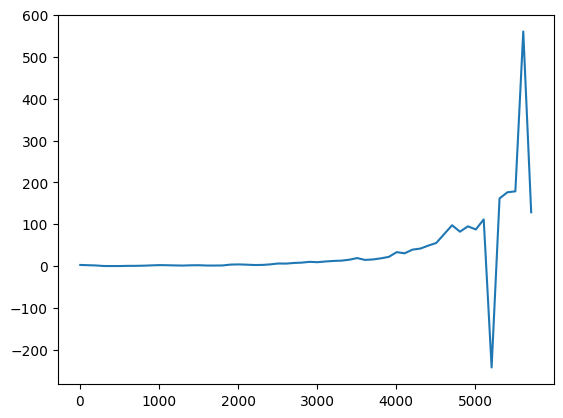

In [ ]:
n = out[1]
x_axis = range(n+1,AMZN.shape[0]-10,100)
y_axis = []
for i in x_axis:
  y_axis.append(time_regression(AMZN,n,i)[0])

plt.plot(x_axis,y_axis)